# Prva kontrolna tačka: Predikcija uspešnosti mobilne aplikacije
**Studenti:** Luka Savkov (E2 63/2025), Stefan Bogdanović (R2 40/2024)  
**Predmet:** Sistemi za istraživanje i analizu podataka  
**Tema:** Regresija ocena (Rating) na osnovu metapodataka sa Google Play prodavnice.

---
### Cilj prve kontrolne tačke
Cilj ove faze je priprema podataka, eksplorativna analiza (EDA) i uspostavljanje osnovnog (baseline) modela kako bismo procenili težinu problema.

## 1. Učitavanje i priprema podataka
Koristimo skup podataka *Google Play Store Apps* sa Kaggle platforme.  
Logika za čišćenje podataka (konverzija veličina iz 'k/M/G' u MB, uklanjanje nevalidnih ocena) izdvojena je u modul `utils.py` radi preglednosti.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from utils import load_and_process_data

df = load_and_process_data('Google-Playstore.csv')

print(f"Broj aplikacija nakon čišćenja: {len(df)}")
df[['App Name', 'Category', 'Rating', 'Size_MB', 'Price', 'Content Rating', 'Ad Supported', 'In App Purchases']].head()

Broj aplikacija nakon čišćenja: 1230299


,App Name,Category,Rating,Size_MB,Price,Content Rating,Ad Supported,In App Purchases
1,Ampere Battery Info,Tools,4.4,2.9,0.0,Everyone,True,False
3,Smart City Trichy Public Service Vehicles 17UC...,Communication,5.0,1.8,0.0,Everyone,True,False
6,unlimited 4G data prank free app,Libraries & Demo,4.5,2.5,0.0,Everyone,True,False
7,The Everyday Calendar,Lifestyle,2.0,16.0,0.0,Everyone,False,False
9,Neon 3d Iron Tech Keyboard Theme,Personalization,4.7,3.5,0.0,Everyone,True,False


**Zapažanje:** Podaci su uspešno učitani. Uklonjene su aplikacije koje nemaju ocene (Rating Count = 0) jer one ne doprinose učenju modela.

=== OSNOVNA STATISTIKA SKUPA PODATAKA ===
Ukupan broj analiziranih aplikacija: 1230299
Ukupan broj sirovih kolona u datasetu: 25
Broj atributa odabranih za modeliranje: 7
Broj različitih kategorija: 48
Prosečna veličina aplikacije: 20.49 MB
------------------------------
Odnos Besplatnih i Plaćenih aplikacija:
Besplatne: 1,204,765 (97.92%)
Plaćene:    25,534  (2.08%)


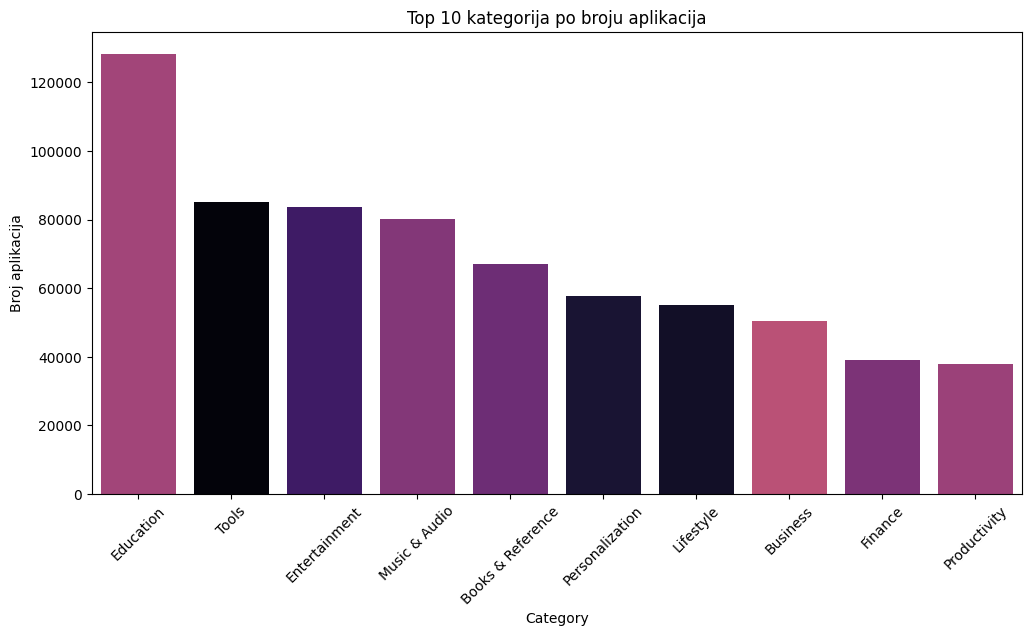

In [12]:
print("=== OSNOVNA STATISTIKA SKUPA PODATAKA ===")
print(f"Ukupan broj analiziranih aplikacija: {df.shape[0]}")
print(f"Ukupan broj sirovih kolona u datasetu: {df.shape[1]}")
features = ['Category', 'Size_MB', 'Minimum Installs', 'Price', 'Content Rating', 'Ad Supported', 'In App Purchases']
print(f"Broj atributa odabranih za modeliranje: {len(features)}")
print(f"Broj različitih kategorija: {df['Category'].nunique()}")
print(f"Prosečna veličina aplikacije: {df['Size_MB'].mean():.2f} MB")
print("-" * 30)
print("Odnos Besplatnih i Plaćenih aplikacija:")

tip_counts = df['Price'].apply(lambda x: 'Besplatne' if x == 0 else 'Plaćene').value_counts()

free_count = tip_counts.get('Besplatne', 0)
paid_count = tip_counts.get('Plaćene', 0)
total = len(df)

print(f"Besplatne: {free_count:,.0f} ({free_count/total:.2%})")
print(f"Plaćene:    {paid_count:,.0f}  ({paid_count/total:.2%})")
print("=" * 30)

plt.figure(figsize=(12, 6))
top_cats = df['Category'].value_counts().nlargest(10).index

sns.countplot(data=df, x='Category', order=top_cats, palette='magma', hue='Category', legend=False)
plt.title('Top 10 kategorija po broju aplikacija')
plt.xticks(rotation=45)
plt.ylabel('Broj aplikacija')
plt.show()

## 2. Eksplorativna analiza podataka
Analiziramo distribuciju ciljne varijable (`Rating`) kako bismo razumeli balans podataka.

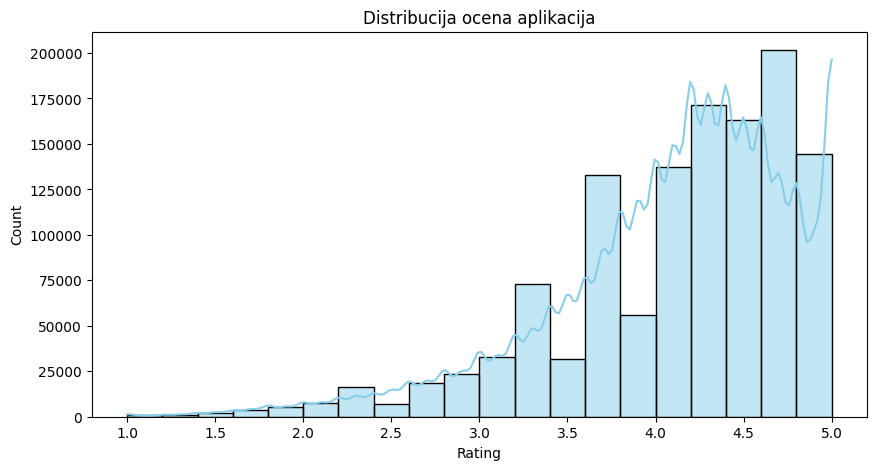

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Rating'], bins=20, kde=True, color='skyblue')
plt.title('Distribucija ocena aplikacija')
plt.xlabel('Rating')
plt.show()

**Zaključak analize:** 

Primećujemo da je distribucija **jako zakrivljena ulevo**. Većina aplikacija ima ocene između 3.5 i 5.0. Ovo ukazuje na to da će model verovatno teže predviđati veoma loše aplikacije (ocene < 2.0) jer ih ima malo u skupu za trening.

Ispitujemo korelaciju između numeričkih atributa (Cena, Veličina, Broj instalacija) i Ocene.

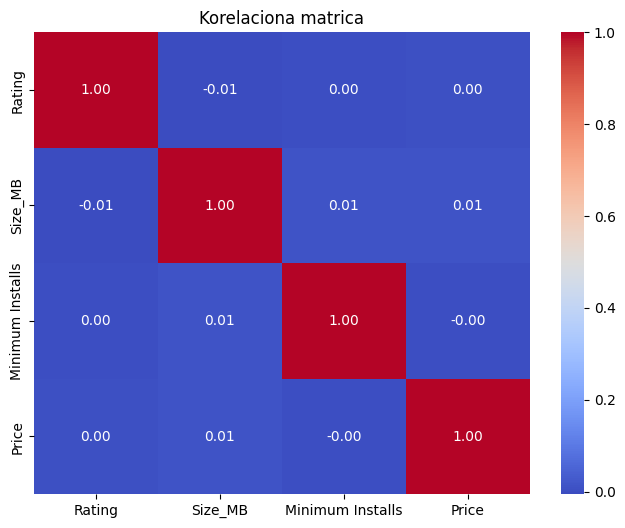

In [4]:
numeric_cols = ['Rating', 'Size_MB', 'Minimum Installs', 'Price']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelaciona matrica')
plt.show()

**Zapažanje:** Korelacije između atributa i ciljne varijable (`Rating`) su veoma niske (blizu 0). Ovo sugeriše da linearna zavisnost nije jaka i opravdava upotrebu složenijih, nelinearnih modela (Random Forest, a kasnije Neuronske mreže).

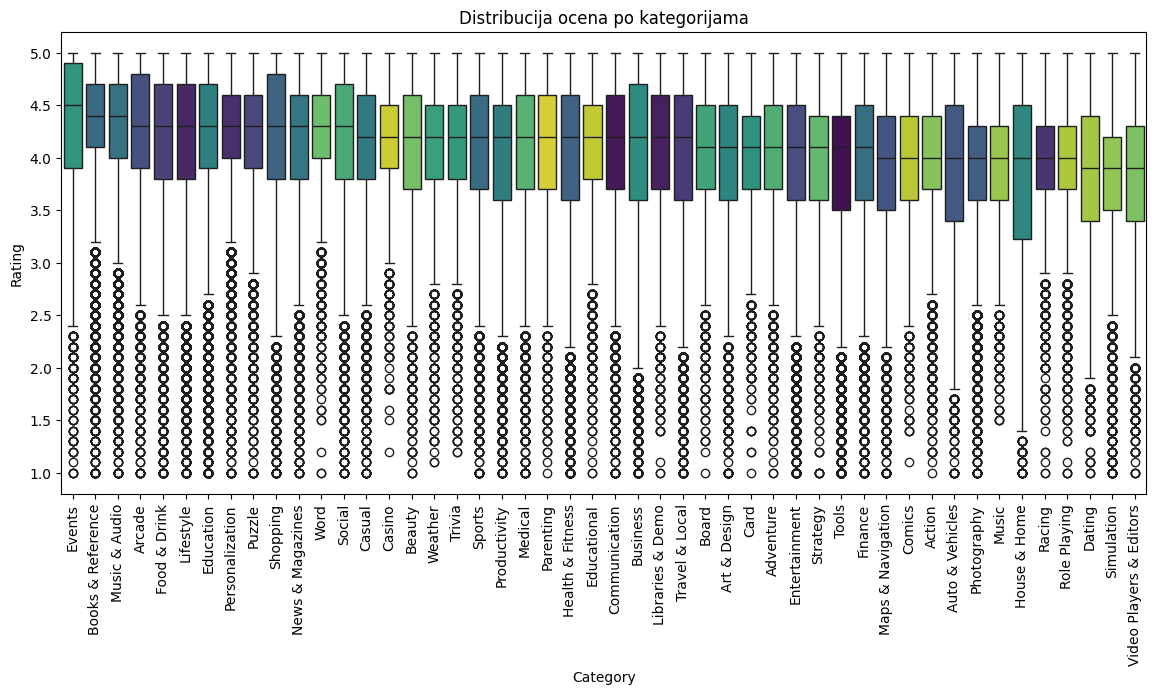

In [8]:
plt.figure(figsize=(14, 6))

sorted_cats = df.groupby('Category')['Rating'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Category', y='Rating', hue='Category', order=sorted_cats, palette='viridis', legend=False)
plt.xticks(rotation=90)
plt.title('Distribucija ocena po kategorijama')
plt.show()

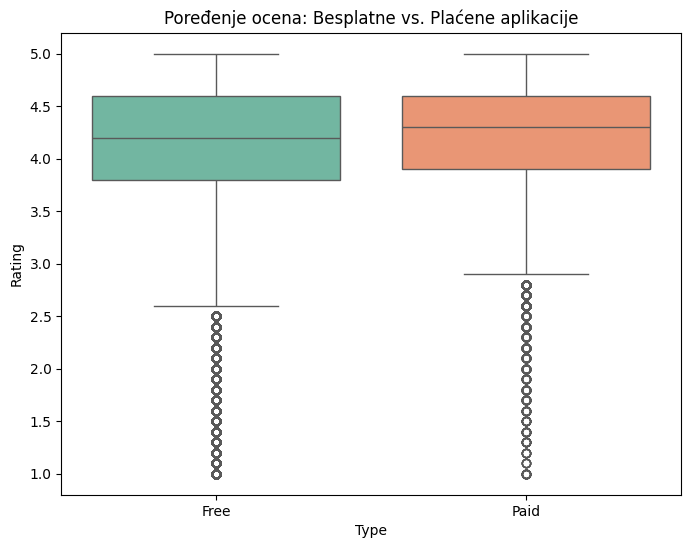

In [ ]:
df['Type'] = df['Price'].apply(lambda x: 'Paid' if x > 0 else 'Free')

plt.figure(figsize=(8, 6))

sns.boxplot(data=df, x='Type', y='Rating', hue='Type', palette='Set2', legend=False)
plt.title('Poređenje ocena: Besplatne vs. Plaćene aplikacije')
plt.show()

df.drop(columns=['Type'], inplace=True)

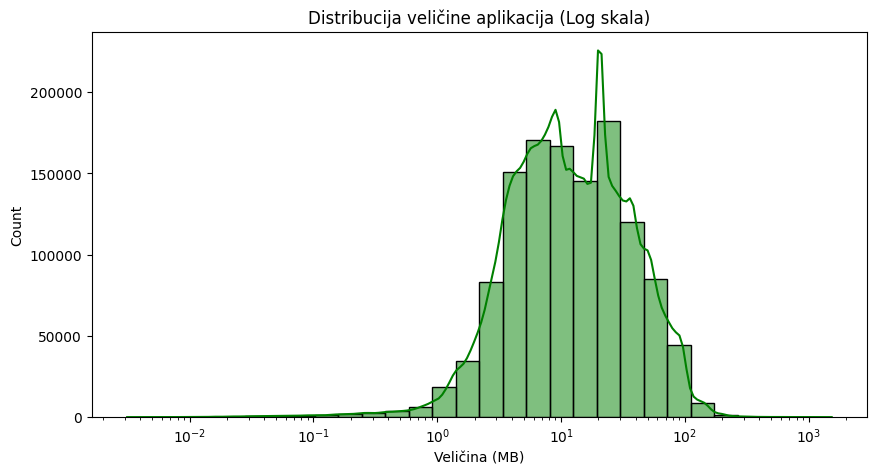

In [7]:
plt.figure(figsize=(10, 5))

sns.histplot(df['Size_MB'], bins=30, kde=True, log_scale=True, color='green')
plt.title('Distribucija veličine aplikacija (Log skala)')
plt.xlabel('Veličina (MB)')
plt.show()

## 3. Baseline Model (Random Forest)
Za prvu kontrolnu tačku koristimo **Random Forest Regressor**. Cilj je uspostaviti "baseline" rezultat (donju granicu performansi) sa kojom ćemo kasnije porediti našu neuronsku mrežu.
Podatke delimo u odnosu 80:20.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

features = ['Category', 'Size_MB', 'Minimum Installs', 'Price', 'Content Rating', 'Ad Supported', 'In App Purchases']
X = df[features].copy()
y = df['Rating']

X['Category'] = LabelEncoder().fit_transform(X['Category'].astype(str))
X['Content Rating'] = LabelEncoder().fit_transform(X['Content Rating'].astype(str))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("Rezultati na test skupu:")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.4f}") 
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

Rezultati na test skupu:
MAE: 0.4930
RMSE: 0.6619
R2 Score: 0.0783


Da bismo razumeli šta model "gleda", prikazujemo važnost atributa.

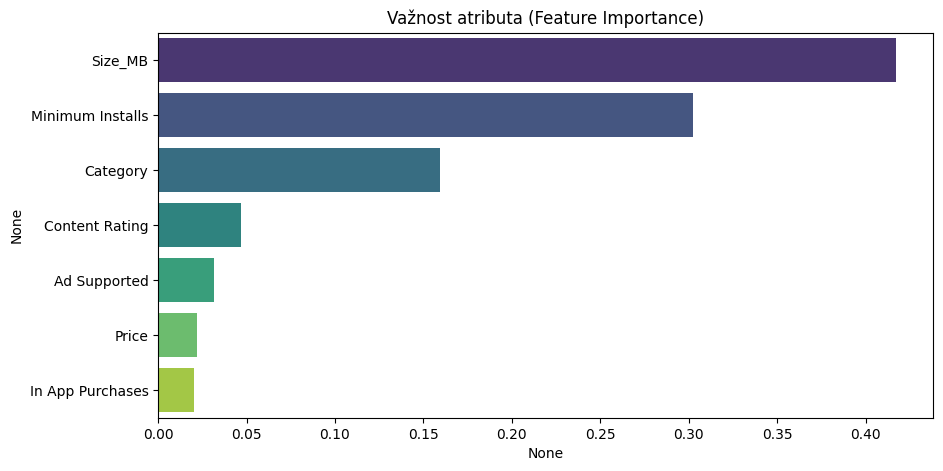

In [ ]:
feature_imp = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=feature_imp, y=feature_imp.index, hue=feature_imp.index, palette='viridis', legend=False)
plt.title('Važnost atributa')
plt.show()

## 4. Zaključak i naredni koraci
1. **Rezultat:** Dobili smo MAE od približno **0.49**. To znači da naš osnovni model promašuje ocenu aplikacije za prosečno pola zvezdice.
2. **Težina problema:** Nizak R2 score (~0.08) potvrđuje hipotezu da veza između metapodataka i ocene nije trivijalna.
3. **Plan za dalje:** U narednoj fazi planiramo implementaciju sopstvene arhitekture Veštačke neuronske mreže (ANN) kako bismo pokušali da uhvatimo nelinearne obrasce koje Random Forest nije uspeo da iskoristi.